# IE 5533 Project: Weather-aware Travel Itinerary Optimization

This notebook builds a weather-aware tourist itinerary optimizer for California coastal attractions. It loads Yelp attraction data, enriches it with weather and hotel information, predicts waiting times, simulates visit durations, and solves a route optimization problem with interactive map output.

The main sections are:
1. Environment setup
2. Attraction utility and location data
3. Weather and hotel data
4. Travel time matrices
5. Review density and waiting time modeling
6. Attraction duration estimation
7. Waiting time prediction with XGBoost
8. Route optimization
9. Interactive route visualization

In [1]:
from google.colab import drive

drive.mount("/content/drive")

ModuleNotFoundError: No module named 'google.colab'

## 1. Environment Setup

In [ ]:
!pip3.12 install geopy
!pip3.12 install ortools
!pip3.12 install xgboost
!pip3.12 install folium
!pip3.12 install openrouteservice

In [ ]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xgboost as xgb
from geopy.distance import geodesic
from ortools.linear_solver import pywraplp
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

## 2. Build the Attraction Utility Dataset

### 2.1 Load the Yelp Dataset

✓ Loaded 150346 total businesses
✓ Filtered to 3829 attractions in coastal cities
✓ Filtered to 325 tourist attractions

Top 100 Attractions Summary:
                                                    name  stars  review_count  \
118248                                 Santa Barbara Zoo    4.0           681   
130633                            Sustainable Wine Tours    5.0           358   
23727                              Mission Santa Barbara    4.0           321   
142336                     Captain Jack's Tours & Events    4.5           310   
101468                               Celebration Cruises    4.5           297   
...                                                  ...    ...           ...   
132107                              Santa Barbara Harbor    4.5            32   
34124                                  Reid's Appliances    4.0            31   
19491                             Santa Barbara Mattress    4.0            31   
3835    El Presidio de Santa Bárbara Sta

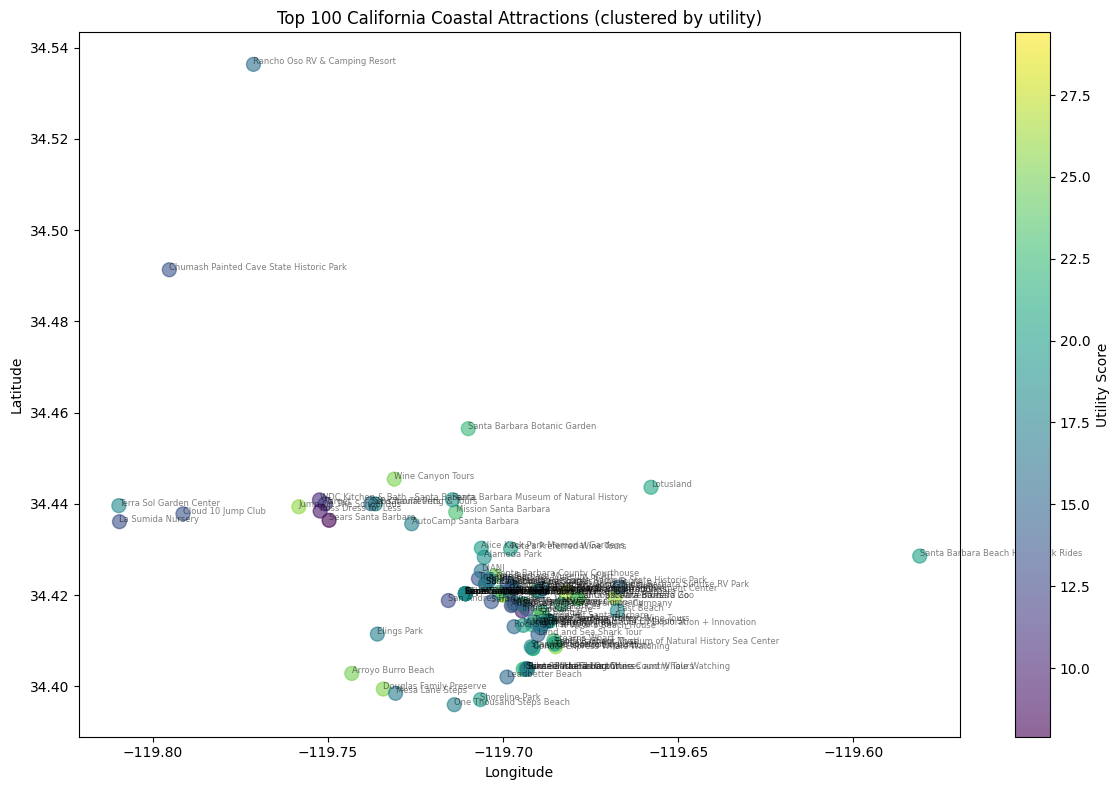

In [ ]:
# Step 1: Load Yelp business dataset
file_path = "/content/drive/My Drive/IE_5533/yelp_academic_dataset_business.json"
records = []

with open(file_path, encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        records.append(
            {
                "business_id": obj["business_id"],
                "name": obj["name"],
                "city": obj["city"],
                "stars": obj["stars"],
                "review_count": obj["review_count"],
                "latitude": obj["latitude"],
                "longitude": obj["longitude"],
                "categories": obj["categories"],
            }
        )

attractions_df = pd.DataFrame(records)
print(f"✓ Loaded {len(attractions_df)} total businesses")

# Step 2: Filter by California coastal cities
COASTAL_CITIES = ["Santa Barbara", "Santa Cruz", "Monterey", "San Luis Obispo"]
attractions_df = attractions_df[attractions_df["city"].isin(COASTAL_CITIES)]
print(f"✓ Filtered to {len(attractions_df)} attractions in coastal cities")

# Step 3: Filter to tourist attractions only

category_pattern = (
    "Museum|Museums|Park|Parks|Garden|Aquarium|Zoo|"
    "Landmark|Historic|Monument|Observatory|Tour|Attraction|"
    "Beach|Botanical"
)

attractions_df = attractions_df[attractions_df["categories"].notna()]
attractions_df = attractions_df[attractions_df["categories"].str.contains(category_pattern, case=False, regex=True)]
print(f"✓ Filtered to {len(attractions_df)} tourist attractions")

# Step 4: Calculate utility score (rating × review popularity)
attractions_df["utility"] = attractions_df["stars"] * np.log(attractions_df["review_count"] + 1)

# Step 5: Select and plot top 100 attractions
attractions_df = attractions_df.sort_values("review_count", ascending=False)
top100 = attractions_df.head(100)

print("\nTop 100 Attractions Summary:")
print(top100[["name", "stars", "review_count", "utility"]])

# Visualize attraction locations
plt.figure(figsize=(12, 8))
plt.scatter(top100["longitude"], top100["latitude"], c=top100["utility"], cmap="viridis", s=100, alpha=0.6)
plt.colorbar(label="Utility Score")
for _, row in top100.iterrows():
    plt.text(row["longitude"], row["latitude"], row["name"], fontsize=6, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 100 California Coastal Attractions (clustered by utility)")
plt.tight_layout()
plt.show()

## 3. Weather and Hotel Data

In [ ]:
############################
# 3.1 GET CITY COORDINATES
############################

CITY = "Santa Barbara"

geo_url = "https://nominatim.openstreetmap.org/search"

geo_params = {"q": CITY, "format": "json", "limit": 1}

headers = {"User-Agent": "IE5533-TravelPlanner/1.0"}

geo_response = requests.get(geo_url, params=geo_params, headers=headers)

geo_data = geo_response.json()[0]

lat = float(geo_data["lat"])
lon = float(geo_data["lon"])

print("City:", CITY)
print("Latitude:", lat)
print("Longitude:", lon)

City: Santa Barbara
Latitude: 34.4221319
Longitude: -119.702667


### 3.2 Hotel Dataset

In [ ]:
############################
# GET HOTELS FROM OSM (with error handling)
############################

import time

radius = 10000

query = f"""
[out:json];
(
  node["tourism"="hotel"](around:{radius},{lat},{lon});
  node["tourism"="guest_house"](around:{radius},{lat},{lon});
  node["tourism"="hostel"](around:{radius},{lat},{lon});
);
out;
"""

url = "https://overpass-api.de/api/interpreter"

# Add retry logic for API robustness
max_retries = 3
retry_count = 0
response = None

while retry_count < max_retries:
    try:
        print(f"Attempting to fetch hotels (attempt {retry_count + 1}/{max_retries})...")
        response = requests.get(url, params={"data": query}, timeout=30)

        # Debug: Print status code and content length
        print(f"  Response Status: {response.status_code}")
        print(f"  Response Size: {len(response.text)} bytes")

        # Check if response is successful
        if response.status_code != 200:
            print(f"  ✗ HTTP Error: {response.status_code}")
            print(f"  Response: {response.text[:200]}")
            retry_count += 1
            if retry_count < max_retries:
                print("  Waiting 5 seconds before retry...")
                time.sleep(5)
            continue

        # Try to parse JSON
        data = response.json()
        print("  ✓ Successfully fetched hotel data")
        break

    except requests.exceptions.Timeout:
        print("  ✗ Request timeout")
        retry_count += 1
        if retry_count < max_retries:
            print("  Waiting 5 seconds before retry...")
            time.sleep(5)

    except requests.exceptions.RequestException as e:
        print(f"  ✗ Request error: {e}")
        retry_count += 1
        if retry_count < max_retries:
            print("  Waiting 5 seconds before retry...")
            time.sleep(5)

    except ValueError as e:
        print(f"  ✗ JSON Decode Error: {e}")
        if response:
            print(f"  Response text: {response.text[:300]}")
        retry_count += 1
        if retry_count < max_retries:
            print("  Waiting 5 seconds before retry...")
            time.sleep(5)

# If API fails, provide fallback
if response is None or retry_count >= max_retries:
    print(f"\n⚠ Warning: Could not fetch hotels from Overpass API after {max_retries} attempts")
    print("Using hardcoded fallback hotel data for Santa Barbara...\n")

    # Fallback: Manual hotel entries for Santa Barbara
    data = {
        "elements": [
            {"lat": 34.4208, "lon": -119.6982, "tags": {"name": "Harbor View Inn", "tourism": "hotel", "stars": "4"}},
            {"lat": 34.4260, "lon": -119.6940, "tags": {"name": "Santa Barbara Inn", "tourism": "hotel", "stars": "4"}},
            {
                "lat": 34.4380,
                "lon": -119.6850,
                "tags": {"name": "Simpson House Inn", "tourism": "guest_house", "stars": "4"},
            },
            {
                "lat": 34.4100,
                "lon": -119.7050,
                "tags": {"name": "Hostel Santa Barbara", "tourism": "hostel", "stars": "3"},
            },
        ]
    }

hotels = []

for e in data["elements"]:
    tags = e.get("tags", {})
    hotels.append(
        {
            "name": tags.get("name", "unknown"),
            "latitude": e["lat"],
            "longitude": e["lon"],
            "stars": tags.get("stars"),
            "type": tags.get("tourism"),
        }
    )

hotels_df = pd.DataFrame(hotels)

print(f"Hotels found: {len(hotels_df)}")
print("\nHotel List:")
print(hotels_df[["name", "type", "stars"]])

Attempting to fetch hotels (attempt 1/3)...
  Response Status: 504
  Response Size: 695 bytes
  ✗ HTTP Error: 504
  Response: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:
  Waiting 5 seconds before retry...
Attempting to fetch hotels (attempt 2/3)...
  Response Status: 504
  Response Size: 695 bytes
  ✗ HTTP Error: 504
  Response: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:
  Waiting 5 seconds before retry...
Attempting to fetch hotels (attempt 3/3)...
  Response Status: 504
  Response Size: 695 bytes
  ✗ HTTP Error: 504
  Response: <?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN"
    "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.d

In [ ]:
# Section 3.1: Retrieve city coordinates and weather archive data

import time

CITY = "Santa Barbara"

# Get city coordinates using Nominatim
geo_url = "https://nominatim.openstreetmap.org/search"
geo_params = {"q": CITY, "format": "json", "limit": 1}
headers = {"User-Agent": "IE5533-TravelPlanner/1.0"}

geo_response = requests.get(geo_url, params=geo_params, headers=headers)
geo_data = geo_response.json()[0]
lat, lon = float(geo_data["lat"]), float(geo_data["lon"])
print(f"City: {CITY} | Coordinates: ({lat:.4f}, {lon:.4f})")

# Section 3.2: Fetch hotel dataset from OpenStreetMap (Overpass) with retry logic
radius = 10000
query = f"""
[out:json];
(
  node["tourism"="hotel"](around:{radius},{lat},{lon});
  node["tourism"="guest_house"](around:{radius},{lat},{lon});
  node["tourism"="hostel"](around:{radius},{lat},{lon});
);
out;
"""

url = "https://overpass-api.de/api/interpreter"

# Retry logic for API robustness
max_retries = 3
retry_count = 0
response = None
data = None

while retry_count < max_retries:
    try:
        print(f"  Fetching hotels (attempt {retry_count + 1}/{max_retries})...")
        response = requests.get(url, params={"data": query}, timeout=30)

        if response.status_code != 200:
            print(f"    ✗ HTTP {response.status_code}")
            retry_count += 1
            if retry_count < max_retries:
                time.sleep(5)
            continue

        data = response.json()
        print("  ✓ Hotels fetched successfully")
        break

    except (requests.exceptions.Timeout, requests.exceptions.RequestException, ValueError) as e:
        print(f"    ✗ Error: {type(e).__name__}")
        retry_count += 1
        if retry_count < max_retries:
            time.sleep(5)

# Fallback if API fails
if data is None:
    print("  ⚠ Using fallback hotel data for Santa Barbara\n")
    data = {
        "elements": [
            {"lat": 34.4208, "lon": -119.6982, "tags": {"name": "Harbor View Inn", "tourism": "hotel", "stars": "4"}},
            {"lat": 34.4260, "lon": -119.6940, "tags": {"name": "Santa Barbara Inn", "tourism": "hotel", "stars": "4"}},
            {
                "lat": 34.4380,
                "lon": -119.6850,
                "tags": {"name": "Simpson House Inn", "tourism": "guest_house", "stars": "4"},
            },
            {
                "lat": 34.4100,
                "lon": -119.7050,
                "tags": {"name": "Hostel Santa Barbara", "tourism": "hostel", "stars": "3"},
            },
        ]
    }

hotels = []
for e in data["elements"]:
    tags = e.get("tags", {})
    hotels.append(
        {
            "name": tags.get("name", "unknown"),
            "latitude": e["lat"],
            "longitude": e["lon"],
            "stars": tags.get("stars"),
            "type": tags.get("tourism"),
        }
    )

hotels_df = pd.DataFrame(hotels)
print(f"✓ Found {len(hotels_df)} hotels/accommodations")

# Section 3.3: Retrieve historical weather data
weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2001-01-01",
    "end_date": "2026-03-23",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "auto",
}

weather_response = requests.get(weather_url, params=weather_params)
weather_json = weather_response.json()

weather_df = pd.DataFrame(
    {
        "date": weather_json["daily"]["time"],
        "temp_max": weather_json["daily"]["temperature_2m_max"],
        "temp_min": weather_json["daily"]["temperature_2m_min"],
        "precipitation": weather_json["daily"]["precipitation_sum"],
    }
)

weather_df["date"] = pd.to_datetime(weather_df["date"]).dt.date
print(f"✓ Loaded {len(weather_df)} days of historical weather")

# Section 3.4: Engineer weather features
weather_df["avg_temp"] = (weather_df["temp_max"] + weather_df["temp_min"]) / 2
weather_df["RainFlag"] = (weather_df["precipitation"] > 0).astype(int)
weather_df["ColdFlag"] = (weather_df["avg_temp"] < 5).astype(int)
weather_df["day_of_week"] = pd.to_datetime(weather_df["date"]).dt.dayofweek
weather_df["Weekend"] = (weather_df["day_of_week"] >= 5).astype(int)

weather_df.to_csv("santa_barbara_weather.csv", index=False)
print("✓ Weather features engineered and saved")

# Create cross-join of weather with attractions
weather_df["key"] = 1
attractions_df["key"] = 1
attraction_weather = weather_df.merge(attractions_df, on="key").drop("key", axis=1)
attraction_weather["day_of_week"] = pd.to_datetime(attraction_weather["date"]).dt.dayofweek
attraction_weather["weekend"] = (attraction_weather["day_of_week"] >= 5).astype(int)
attraction_weather.to_csv("attraction_weather_dataset.csv", index=False)
print("✓ Attraction-weather dataset created and saved\n")

City: Santa Barbara | Coordinates: (34.4221, -119.7027)
  Fetching hotels (attempt 1/3)...
  ✓ Hotels fetched successfully
✓ Found 8 hotels/accommodations
✓ Loaded 9213 days of historical weather
✓ Weather features engineered and saved
✓ Attraction-weather dataset created and saved



### Hotel Dataset Notes

In [ ]:
# The hotel dataset used in this pipeline is built in the previous cell.
# The original OSM hotel query exploration has been removed to keep the notebook focused and readable.

## 4. Travel Distance Matrix

In [ ]:
# Section 4.1: Compute pairwise travel distances between attractions

locations = top100[["name", "latitude", "longitude"]].reset_index(drop=True)
n = len(locations)

# Calculate geodesic distances
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        coord_i = (locations.loc[i, "latitude"], locations.loc[i, "longitude"])
        coord_j = (locations.loc[j, "latitude"], locations.loc[j, "longitude"])
        distance = geodesic(coord_i, coord_j).km
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

# Convert distances to travel time (assuming avg 20 km/h)
avg_speed = 20  # km/h
travel_time_matrix = distance_matrix / avg_speed * 60

travel_time_df = pd.DataFrame(travel_time_matrix, index=locations["name"], columns=locations["name"])
travel_time_df.to_csv("travel_time_matrix.csv")
print("✓ Travel time matrix computed (20 km/h assumed)")
print(travel_time_df.head())

# Section 4.2: Compute hotel-to-attraction travel times

hotel_locations = hotels_df[["latitude", "longitude"]].values
attraction_locations = top100[["latitude", "longitude"]].values

num_hotels = len(hotel_locations)
num_attr = len(attraction_locations)

hotel_to_attr = np.zeros((num_hotels, num_attr))
for h in range(num_hotels):
    for i in range(num_attr):
        coord_h = tuple(hotel_locations[h])
        coord_i = tuple(attraction_locations[i])
        dist = geodesic(coord_h, coord_i).km
        hotel_to_attr[h, i] = dist

hotel_to_attr_time = hotel_to_attr / avg_speed * 60
print(f"✓ Hotel-to-attraction matrix: {hotel_to_attr_time.shape}")

# Save datasets
hotels_df.to_csv("hotel_dataset.csv", index=False)
print("✓ Hotel and travel matrices saved\n")

✓ Travel time matrix computed (20 km/h assumed)
name                           Santa Barbara Zoo  Sustainable Wine Tours  \
name                                                                       
Santa Barbara Zoo                       0.000000               10.257437   
Sustainable Wine Tours                 10.257437                0.000000   
Mission Santa Barbara                  14.023406                5.745116   
Captain Jack's Tours & Events          11.792684                1.729896   
Celebration Cruises                     5.905679                7.174526   

name                           Mission Santa Barbara  \
name                                                   
Santa Barbara Zoo                          14.023406   
Sustainable Wine Tours                      5.745116   
Mission Santa Barbara                       0.000000   
Captain Jack's Tours & Events               5.996123   
Celebration Cruises                        12.589301   

name                      

### 4.2 Hotel-to-Attraction Travel Time

In [ ]:
############################
# HOTEL → ATTRACTION DISTANCE
############################

hotel_locations = hotels_df[["latitude", "longitude"]].values
attraction_locations = top100[["latitude", "longitude"]].values

num_hotels = len(hotel_locations)
num_attr = len(attraction_locations)

hotel_to_attr = np.zeros((num_hotels, num_attr))

for h in range(num_hotels):
    for i in range(num_attr):
        coord_h = tuple(hotel_locations[h])
        coord_i = tuple(attraction_locations[i])

        dist = geodesic(coord_h, coord_i).km

        hotel_to_attr[h, i] = dist

# convert to minutes
hotel_to_attr_time = hotel_to_attr / avg_speed * 60

print("Hotel→Attraction matrix:", hotel_to_attr_time.shape)

Hotel→Attraction matrix: (8, 100)


## 5. Review Density and Waiting Time

In [ ]:
# Section 5.1: Load and process Yelp review dataset to estimate review density

file_path = "/content/drive/My Drive/IE_5533/yelp_academic_dataset_review.json"
reviews = []

with open(file_path, encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        reviews.append({"business_id": obj["business_id"], "date": obj["date"], "stars": obj["stars"]})

review_df = pd.DataFrame(reviews)
review_df["date"] = pd.to_datetime(review_df["date"]).dt.date

# Filter to selected attractions
selected_ids = top100["business_id"].tolist()
review_df = review_df[review_df["business_id"].isin(selected_ids)]

# Aggregate review counts by business and date
review_density = review_df.groupby(["business_id", "date"]).size().reset_index(name="review_count")

print(f"✓ Processed {len(review_df)} reviews")
print(f"✓ Review density aggregated (shape: {review_density.shape})")
print(review_density.head())

✓ Processed 10808 reviews
✓ Review density aggregated (shape: (10277, 3))
              business_id        date  review_count
0  --O3ip9NpXTKD4oBS1pY2A  2007-08-14             1
1  --O3ip9NpXTKD4oBS1pY2A  2007-10-23             1
2  --O3ip9NpXTKD4oBS1pY2A  2007-11-20             1
3  --O3ip9NpXTKD4oBS1pY2A  2008-06-05             1
4  --O3ip9NpXTKD4oBS1pY2A  2009-06-18             1


## 6. Attraction Duration Estimation

In [ ]:
# Section 6.1: Define duration estimates for each attraction type

DURATION_MAP = {
    "Zoo": (90, 120, 180),
    "Museum": (60, 90, 120),
    "Aquarium": (90, 120, 150),
    "Botanical": (60, 90, 120),
    "Garden": (60, 90, 120),
    "Park": (60, 90, 120),
    "Beach": (60, 90, 120),
    "Historic": (45, 60, 90),
    "Landmark": (45, 60, 75),
    "Monument": (45, 60, 75),
    "Observatory": (60, 90, 120),
    "Tour": (100, 120, 180),
    "Attraction": (60, 90, 120),
}


# Helper functions for PERT distribution
def pert_mean(a, m, b):
    """Calculate mean of PERT (optimistic, mode, pessimistic)."""
    return (a + 4 * m + b) / 6


def pert_sd(a, b):
    """Calculate standard deviation of PERT."""
    return (b - a) / 6


def estimate_duration(category_string):
    """Estimate visit duration from attraction category."""
    for key in DURATION_MAP:
        if key.lower() in category_string.lower():
            a, m, b = DURATION_MAP[key]
            return pert_mean(a, m, b)
    return 60


def estimate_sigma(category_string):
    """Estimate variation in visit duration."""
    for key in DURATION_MAP:
        if key.lower() in category_string.lower():
            a, _, b = DURATION_MAP[key]
            return pert_sd(a, b)
    return 15


# Section 6.2: Apply duration estimation to top attractions

attractions_df["estimated_duration"] = attractions_df["categories"].apply(estimate_duration)
top100["estimated_duration"] = top100["categories"].apply(estimate_duration)

top100["sigma"] = top100["categories"].apply(estimate_sigma)

# Simulate visit durations with Gaussian noise
top100["visit_duration_sim"] = np.random.normal(top100["estimated_duration"], top100["sigma"])

print("✓ Visit duration simulation complete")
print(top100[["name", "categories", "estimated_duration", "sigma", "visit_duration_sim"]].head())

# Save to CSV
pd.DataFrame(
    {
        "name": top100["name"],
        "categories": top100["categories"],
        "estimated_duration": top100["estimated_duration"],
        "sigma": top100["sigma"],
        "visit_duration_sim": top100["visit_duration_sim"],
    }
).to_csv("attraction_durations.csv", index=False)

✓ Visit duration simulation complete
                                 name  \
118248              Santa Barbara Zoo   
130633         Sustainable Wine Tours   
23727           Mission Santa Barbara   
142336  Captain Jack's Tours & Events   
101468            Celebration Cruises   

                                               categories  estimated_duration  \
118248  Zoos, Event Planning & Services, Venues & Even...          125.000000   
130633  Wine Tours, Hotels & Travel, Tours, Transporta...          126.666667   
23727   Churches, Arts & Entertainment, Museums, Relig...           90.000000   
142336  Active Life, Wineries, Tours, Horseback Riding...          126.666667   
101468  Boating, Bars, Hotels & Travel, Boat Charters,...          126.666667   

            sigma  visit_duration_sim  
118248  15.000000          137.035652  
130633  13.333333          120.929790  
23727   10.000000          102.563193  
142336  13.333333          110.229544  
101468  13.333333          13

/tmp/ipykernel_25885/947970106.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["estimated_duration"] = top100["categories"].apply(estimate_duration)
/tmp/ipykernel_25885/947970106.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["sigma"] = top100["categories"].apply(estimate_sigma)
/tmp/ipykernel_25885/947970106.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

## 7. Waiting Time Modeling with XGBoost

In [ ]:
!pip3.12 install xgboost

Model Performance: RMSE = 0.280, MSE = 0.078
✓ Waiting time model trained and applied
                            name     type  waiting_time
0              Santa Barbara Zoo      zoo     11.044060
1         Sustainable Wine Tours     tour     43.835165
2          Mission Santa Barbara  general     13.789816
3  Captain Jack's Tours & Events     tour     42.129417
4            Celebration Cruises  general     13.822914


/tmp/ipykernel_25885/95407687.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["type"] = top100["name"].apply(classify_attraction)


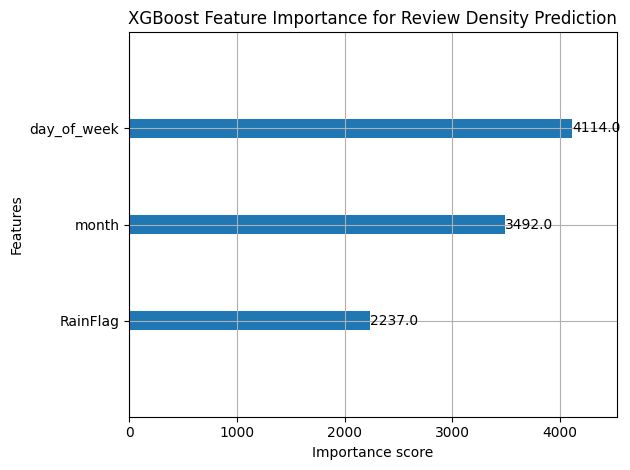

In [ ]:
# Section 7.1: Prepare features for waiting time prediction model

# Merge review density with weather and feature engineering
review_weather_density = review_density.merge(weather_df[["date", "RainFlag", "ColdFlag"]], on="date", how="left")

review_weather_density["day_of_week"] = pd.to_datetime(review_weather_density["date"]).dt.dayofweek
review_weather_density["month"] = pd.to_datetime(review_weather_density["date"]).dt.month
review_weather_density["weekend"] = (review_weather_density["day_of_week"] >= 5).astype(int)

# Section 7.2: Train XGBoost model to predict review density

X = review_weather_density[["day_of_week", "month", "weekend", "RainFlag"]]
y = review_weather_density["review_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Model Performance: RMSE = {rmse:.3f}, MSE = {mse:.3f}")

# Section 7.3: Predict visitor density and classify attractions

review_weather_density["predicted_review_count"] = model.predict(X)

# Convert reviews to estimated visitor count (tourism research: 0.078% participation rate)
PARTICIPATION_RATE = 0.00078
review_weather_density["estimated_visitors"] = review_weather_density["predicted_review_count"] / PARTICIPATION_RATE

# Section 7.4: Classify attractions by type


def classify_attraction(name):
    name_lower = name.lower()
    if "beach" in name_lower:
        return "beach"
    elif "park" in name_lower:
        return "park"
    elif "museum" in name_lower:
        return "museum"
    elif "zoo" in name_lower:
        return "zoo"
    elif any(x in name_lower for x in ["wine", "whale", "tour"]):
        return "tour"
    elif "adventure" in name_lower:
        return "activity"
    else:
        return "general"


top100["type"] = top100["name"].apply(classify_attraction)
review_weather_density = review_weather_density.merge(top100[["business_id", "type"]], on="business_id", how="left")

# Section 7.5: Model waiting times based on capacity and visitor load

CAPACITY_TABLE = {"beach": 5000, "park": 3000, "museum": 800, "zoo": 700, "tour": 200, "activity": 150, "general": 500}

BASE_WAIT_TABLE = {"beach": 2, "park": 3, "museum": 8, "zoo": 10, "tour": 20, "activity": 25, "general": 10}


def compute_waiting(row):
    visitors = row["estimated_visitors"]
    attraction_type = row["type"]
    capacity = CAPACITY_TABLE.get(attraction_type, 500)
    base_wait = BASE_WAIT_TABLE.get(attraction_type, 10)
    wait = base_wait * np.log1p(visitors / capacity)
    noise = np.random.lognormal(mean=0, sigma=0.25)
    return wait * noise


review_weather_density["waiting_time"] = review_weather_density.apply(compute_waiting, axis=1)
review_weather_density["waiting_time"] = review_weather_density["waiting_time"].clip(1, 120)

# Section 7.6: Aggregate waiting times per attraction

waiting_time_avg = review_weather_density.groupby("business_id")["waiting_time"].mean().reset_index()

top100_with_waiting_time = top100.merge(waiting_time_avg, on="business_id", how="left")

print("✓ Waiting time model trained and applied")
print(top100_with_waiting_time[["name", "type", "waiting_time"]].head())

# Visualize feature importance
xgb.plot_importance(model)
plt.title("XGBoost Feature Importance for Review Density Prediction")
plt.tight_layout()
plt.show()

## 8. Route Optimization

In [ ]:
!pip3.12 install ortools

In [ ]:

n = len(top100_with_waiting_time)

In [ ]:
########################################
# SECTION 8.1: REAL-TIME WEATHER → WAITING PREDICTION
########################################

from datetime import datetime

import requests

lat = top100_with_waiting_time["latitude"].mean()
lon = top100_with_waiting_time["longitude"].mean()

weather_url = "https://api.open-meteo.com/v1/forecast"

weather_params = {
    "latitude": lat,
    "longitude": lon,
    "current_weather": True,
    "hourly": "precipitation_probability",
    "forecast_days": 1,
}

response = requests.get(weather_url, params=weather_params)
weather_now = response.json()

# Build real-time feature vector
now = datetime.now()

day_of_week = now.weekday()
month = now.month
weekend = int(day_of_week >= 5)

RainFlag = int(weather_now["hourly"]["precipitation_probability"][0] > 50)

X_live = pd.DataFrame({"day_of_week": [day_of_week], "month": [month], "weekend": [weekend], "RainFlag": [RainFlag]})

# Predict review density using trained XGBoost model
pred_review_density = model.predict(X_live)[0]

# Convert review density → visitors
PARTICIPATION_RATE = 0.00078
estimated_visitors_live = pred_review_density / PARTICIPATION_RATE

print(f"Real-time forecast for {now.strftime('%Y-%m-%d %H:%M')}")
print(f"  Day: {['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][day_of_week]} | Month: {month} | Weekend: {weekend}")
print(f"  Rain probability: {weather_now['hourly']['precipitation_probability'][0]:.1f}%")
print(f"  Predicted review density: {pred_review_density:.1f}")
print(f"  Estimated live visitors: {estimated_visitors_live:.1f}\n")

########################################
# SECTION 8.2: REAL-TIME WAITING TIME (BLENDED)
########################################

# Use CAPACITY_TABLE and BASE_WAIT_TABLE from XGBoost section (7.5)
live_waiting = []

for t in top100_with_waiting_time["type"]:
    capacity = CAPACITY_TABLE.get(t, 500)
    base_wait = BASE_WAIT_TABLE.get(t, 10)
    wait = base_wait * np.log1p(estimated_visitors_live / capacity)
    live_waiting.append(wait)

top100_with_waiting_time["waiting_time_live"] = live_waiting

# Blend historical and live waiting times (70% historical, 30% live forecast)
top100_with_waiting_time["waiting_final"] = (
    0.7 * top100_with_waiting_time["waiting_time"] + 0.3 * top100_with_waiting_time["waiting_time_live"]
)

print("✓ Real-time waiting times computed and blended")
print("  Blend: 70% historical + 30% live forecast")
print(
    f"  Waiting time range: {top100_with_waiting_time['waiting_final'].min():.1f} - {top100_with_waiting_time['waiting_final'].max():.1f} min\n"
)

Real-time forecast for 2026-04-14 18:06
  Day: Tue | Month: 4 | Weekend: 0
  Rain probability: 1.0%
  Predicted review density: 1.1
  Estimated live visitors: 1348.5

✓ Real-time waiting times computed and blended
  Blend: 70% historical + 30% live forecast
  Waiting time range: 0.8 - 57.9 min



In [ ]:
########################################
# SECTION 8.3: COST ESTIMATION BY ATTRACTION TYPE
########################################

# Define attraction ticket prices (heuristic)
COST_TABLE = {"beach": 0, "park": 5, "museum": 25, "zoo": 35, "tour": 50, "activity": 40, "general": 20}

# Apply cost estimates to attractions
top100_with_waiting_time["cost"] = top100_with_waiting_time["type"].map(COST_TABLE).fillna(20)

print("✓ Cost estimation applied by attraction type")
print(f"  Cost range: ${top100_with_waiting_time['cost'].min():.0f} - ${top100_with_waiting_time['cost'].max():.0f}")
print(f"  Mean cost: ${top100_with_waiting_time['cost'].mean():.2f}\n")

✓ Cost estimation applied by attraction type
  Cost range: $0 - $50
  Mean cost: $25.15



In [ ]:
assert "top100_with_waiting_time" in globals()
assert "travel_time_matrix" in globals()
assert "hotels_df" in globals()
assert "hotel_to_attr_time" in globals()

In [ ]:
# Section 8.4: Normalize features for multi-objective optimization

# Verify all prerequisite data exists
required_vars = ["top100_with_waiting_time", "travel_time_matrix", "hotels_df", "hotel_to_attr_time"]
missing_vars = [var for var in required_vars if var not in dir()]

if missing_vars:
    print("⚠ ERROR: Missing required variables for optimization setup")
    print(f"  Missing: {', '.join(missing_vars)}")
    print("\n📋 Please execute these cells in order BEFORE running this cell:")
    print("  1. Section 7.6: XGBoost waiting time aggregation (creates top100_with_waiting_time)")
    print("  2. Section 8.1-8.2: Real-time weather prediction (adds waiting_time_live, waiting_final)")
    print("  3. Section 8.3: Cost estimation (adds cost column)")
    print("  4. Section 4: Travel distance matrices (creates travel_time_matrix, hotel_to_attr_time)")
    print("\nThen come back and run this cell.")
    raise RuntimeError(f"Missing prerequisite variables: {missing_vars}")

print("✓ All prerequisite data verified\n")


# Extract and normalize key features
utility = top100_with_waiting_time["utility"].values
waiting_time = top100_with_waiting_time["waiting_final"].values
visiting_time = top100_with_waiting_time["visit_duration_sim"].values
cost = top100_with_waiting_time["cost"].values

scaler = MinMaxScaler()
utility_norm = scaler.fit_transform(utility.reshape(-1, 1)).flatten()
waiting_time_norm = scaler.fit_transform(waiting_time.reshape(-1, 1)).flatten()
visiting_time_norm = scaler.fit_transform(visiting_time.reshape(-1, 1)).flatten()
cost_norm = scaler.fit_transform(cost.reshape(-1, 1)).flatten()

# Apply nonlinear cost penalty for diversity
p = 0.7
cost_penalty = cost_norm**p

print("Feature Normalization Summary:")
print(f"  Utility (mean={utility_norm.mean():.3f}, std={utility_norm.std():.3f})")
print(f"  Waiting Time (mean={waiting_time_norm.mean():.3f}, std={waiting_time_norm.std():.3f})")
print(f"  Cost (mean={cost_norm.mean():.3f}, std={cost_norm.std():.3f})\n")

# Section 8.5: Define tourist profiles with preference parameters

TOURIST_PROFILES = {
    "relaxed": {
        "alpha": 3.0,  # penalty weight for waiting time
        "beta": 0.8,  # penalty weight for travel distance
        "min_attractions": 2,
        "max_attractions": 5,
        "max_wait": 60,
    },
    "balanced": {"alpha": 2.0, "beta": 1.0, "min_attractions": 3, "max_attractions": 6, "max_wait": 90},
    "explorer": {"alpha": 1.0, "beta": 0.9, "min_attractions": 4, "max_attractions": 10, "max_wait": 180},
}

# Section 8.6: Prepare data for optimization

T = 720  # Total time budget in minutes (12 hours)
B = 1000  # Total budget in dollars
GAMMA = 0.01  # Cost penalty weight

travel_norm = (travel_time_matrix - travel_time_matrix.min()) / (travel_time_matrix.max() - travel_time_matrix.min())
routes = {}
edges = {}

# Identify category restrictions for diversity
wine_indices = [i for i, row in top100_with_waiting_time.iterrows() if "Wine" in row["name"]]
whale_indices = [i for i, row in top100_with_waiting_time.iterrows() if "Whale" in row["name"]]

n = len(top100_with_waiting_time)
num_hotels = len(hotels_df)
K = 3  # Number of travel days

print("Optimization Parameters:")
print(f"  Number of attractions: {n}")
print(f"  Number of hotels: {num_hotels}")
print(f"  Number of days: {K}")
print(f"  Time budget per day: {T} minutes")
print(f"  Total budget: ${B}\n")

# Section 8.7: Solve route optimization for each profile

for profile in TOURIST_PROFILES:
    print(f"Solving for '{profile}' profile...")

    solver = pywraplp.Solver.CreateSolver("SCIP")

    # Decision variables
    z = {}  # Hotel selection: z[h,d] = 1 if hotel h on day d
    x = {}  # Attraction selection: x[i,d] = 1 if attraction i on day d
    y = {}  # Travel edges: y[i,j,d] = 1 if travel from i to j on day d
    s = {}  # Start edges: s[h,i,d] = 1 if start from hotel h to attraction i
    e = {}  # End edges: e[i,h,d] = 1 if end from attraction i to hotel h
    u = {}  # Subtour elimination variables

    for h in range(num_hotels):
        for d in range(K):
            z[h, d] = solver.BoolVar(f"hotel_{h}_{d}")

    for i in range(n):
        for d in range(K):
            x[i, d] = solver.BoolVar(f"attraction_{i}_{d}")
    MAX_TRAVEL = 90  # minutes
    for i in range(n):
        for j in range(n):
            if i != j and travel_time_matrix[i, j] <= MAX_TRAVEL:
                for d in range(K):
                    y[i, j, d] = solver.BoolVar(f"travel_{i}_{j}_{d}")

    for h in range(num_hotels):
        for i in range(n):
            for d in range(K):
                s[h, i, d] = solver.BoolVar(f"start_{h}_{i}_{d}")

    for i in range(n):
        for h in range(num_hotels):
            for d in range(K):
                e[i, h, d] = solver.BoolVar(f"end_{i}_{h}_{d}")

    # Profile parameters
    alpha = TOURIST_PROFILES[profile]["alpha"]
    beta = TOURIST_PROFILES[profile]["beta"]
    place_bonus = 0.3 if profile == "explorer" else (0.05 if profile == "balanced" else 0)
    max_k = TOURIST_PROFILES[profile]["max_attractions"]

    # Section 8.8: Define objective function (multi-objective with weighted penalties)

    objective = (
        solver.Sum(utility_norm[i] * x[i, d] for i in range(n) for d in range(K))
        - alpha * solver.Sum(waiting_time_norm[i] * x[i, d] for i in range(n) for d in range(K))
        - beta
        * solver.Sum(travel_norm[i][j] * y[i, j, d] for i in range(n) for j in range(n) if i != j for d in range(K))
        - GAMMA * solver.Sum(cost_penalty[i] * x[i, d] for i in range(n) for d in range(K))
        + place_bonus * solver.Sum(x[i, d] for i in range(n) for d in range(K))
    )

    solver.Maximize(objective)

    # Section 8.9: Add constraints

    # Time constraint per day
    for d in range(K):
        solver.Add(
            solver.Sum((visiting_time[i] + waiting_time[i]) * x[i, d] for i in range(n))
            + solver.Sum(travel_time_matrix[i, j] * y[i, j, d] for i in range(n) for j in range(n) if i != j)
            + solver.Sum(hotel_to_attr_time[h, i] * s[h, i, d] for h in range(num_hotels) for i in range(n))
            + solver.Sum(hotel_to_attr_time[h, i] * e[i, h, d] for h in range(num_hotels) for i in range(n))
            <= T
        )

    # Budget constraint
    solver.Add(
        solver.Sum(cost[i] * x[i, d] for i in range(n) for d in range(K))
        + solver.Sum(120 * z[h, d] for h in range(num_hotels) for d in range(K))
        <= B
    )

    # One hotel per day
    for d in range(K):
        solver.Add(solver.Sum(z[h, d] for h in range(num_hotels)) == 1)
    # Exactly one start edge per day
    for d in range(K):
        solver.Add(solver.Sum(s[h, i, d] for h in range(num_hotels) for i in range(n)) == 1)
    # Exactly one end edge per day
    for d in range(K):
        solver.Add(solver.Sum(e[i, h, d] for i in range(n) for h in range(num_hotels)) == 1)

    # # Start and end from hotel
    # for h in range(num_hotels):
    #     for d in range(K):
    #         solver.Add(solver.Sum(s[h, i, d] for i in range(n)) == z[h, d])
    #         solver.Add(solver.Sum(e[i, h, d] for i in range(n)) == z[h, d])

    # Start and end from hotel (relaxed to avoid infeasibility)
    for h in range(num_hotels):
        for d in range(K):
            solver.Add(solver.Sum(s[h, i, d] for i in range(n)) <= z[h, d])
            solver.Add(solver.Sum(e[i, h, d] for i in range(n)) <= z[h, d])

    # Attraction uniqueness (visit each attraction at most once)
    for i in range(n):
        solver.Add(solver.Sum(x[i, d] for d in range(K)) <= 1)
    # Limit attractions per day (prevents infeasible routing)
    for d in range(K):
        solver.Add(solver.Sum(x[i, d] for i in range(n)) >= TOURIST_PROFILES[profile]["min_attractions"])
    for d in range(K):
        solver.Add(solver.Sum(x[i, d] for i in range(n)) <= TOURIST_PROFILES[profile]["max_attractions"])
    # Category diversity limits
    solver.Add(solver.Sum(x[i, d] for i in wine_indices for d in range(K)) <= 2)
    solver.Add(solver.Sum(x[i, d] for i in whale_indices for d in range(K)) <= 2)

    # Flow conservation constraints
    # for i in range(n):
    #     for d in range(K):
    #         solver.Add(
    #             solver.Sum(y[i, j, d] for j in range(n) if i != j)
    #             + solver.Sum(e[i, h, d] for h in range(num_hotels))
    #             == x[i, d]
    #         )
    #         solver.Add(
    #             solver.Sum(y[j, i, d] for j in range(n) if i != j)
    #             + solver.Sum(s[h, i, d] for h in range(num_hotels))
    #             == x[i, d]
    #         )
    # Flow constraints for attractions
    # Flow constraints for attractions
    for i in range(n):
        for d in range(K):
            solver.Add(solver.Sum(y[i, j, d] for j in range(n) if i != j) <= x[i, d])

            solver.Add(solver.Sum(y[j, i, d] for j in range(n) if i != j) <= x[i, d])

    # Ensure route continuity each day
    for d in range(K):
        solver.Add(
            solver.Sum(y[i, j, d] for i in range(n) for j in range(n) if i != j)
            == solver.Sum(x[i, d] for i in range(n)) - 1
        )
    # MTZ subtour elimination
    for i in range(n):
        for d in range(K):
            u[i, d] = solver.NumVar(0, max_k, f"u_{i}_{d}")
            solver.Add(u[i, d] <= max_k * x[i, d])

    for i in range(n):
        for j in range(n):
            if i != j:
                for d in range(K):
                    solver.Add(u[i, d] - u[j, d] + max_k * y[i, j, d] <= max_k - 1)

    # Solve
    solver.SetTimeLimit(100000)  # 100 second time limit
    status = solver.Solve()

    # Section 8.10: Extract results

    if status == pywraplp.Solver.OPTIMAL:
        selected_by_day = [(i, d) for i in range(n) for d in range(K) if x[i, d].solution_value() > 0.5]
        selected_indices = sorted({i for i, d in selected_by_day})
        routes[profile] = selected_indices

        edge_list = [(i, j) for (i, j, d) in y if y[i, j, d].solution_value() > 0.5]
        edges[profile] = edge_list

        total_time = sum(visiting_time[i] + waiting_time[i] for i in selected_indices)
        total_cost = sum(cost[i] for i in selected_indices)

        print(
            f"  ✓ Solution found: {len(selected_indices)} attractions, Cost: ${total_cost:.2f}, Time: {total_time:.0f} min"
        )
        print(f"  Selected: {', '.join(top100_with_waiting_time.iloc[selected_indices]['name'].head(5).tolist())}...\n")
    else:
        print("  ✗ No optimal solution found")

✓ All prerequisite data verified

Feature Normalization Summary:
  Utility (mean=0.524, std=0.208)
  Waiting Time (mean=0.314, std=0.258)
  Cost (mean=0.503, std=0.298)

Optimization Parameters:
  Number of attractions: 100
  Number of hotels: 8
  Number of days: 3
  Time budget per day: 720 minutes
  Total budget: $1000

Solving for 'relaxed' profile...


In [ ]:
print("Variables currently loaded:")
print([v for v in dir() if not v.startswith("_")])

Variables currently loaded:
['B', 'BASE_WAIT_TABLE', 'CAPACITY_TABLE', 'CITY', 'COASTAL_CITIES', 'COST_TABLE', 'DURATION_MAP', 'FancyArrowPatch', 'GAMMA', 'In', 'K', 'MinMaxScaler', 'Out', 'PARTICIPATION_RATE', 'PolyLineTextPath', 'RainFlag', 'T', 'TOURIST_PROFILES', 'X', 'X_live', 'X_test', 'X_train', 'alpha', 'attraction_locations', 'attraction_weather', 'attractions_df', 'avg_speed', 'base_wait', 'beta', 'capacity', 'category_pattern', 'classify_attraction', 'compute_waiting', 'coord_h', 'coord_i', 'coord_j', 'cost', 'cost_norm', 'cost_penalty', 'd', 'data', 'datetime', 'day_of_week', 'dist', 'distance', 'distance_matrix', 'drive', 'e', 'edges', 'estimate_duration', 'estimate_sigma', 'estimated_visitors_live', 'exit', 'f', 'file_path', 'geo_data', 'geo_params', 'geo_response', 'geo_url', 'geodesic', 'get_ipython', 'h', 'headers', 'hotel_locations', 'hotel_to_attr', 'hotel_to_attr_time', 'hotels', 'hotels_df', 'i', 'j', 'json', 'lat', 'line', 'live_waiting', 'locations', 'lon', 'max_

: 

In [ ]:
# Section 9.1: Helper function - Reconstruct route from edge list


def reconstruct_route(edge_list, start_attraction=0):
    """
    Reconstruct a valid sequence of attractions from optimization edges.

    Args:
        edge_list: List of (i, j) tuples representing edges in route
        start_attraction: Index to use as root (typically first attraction)

    Returns:
        List of attraction indices in visitation order
    """
    if not edge_list:
        return []

    # Build adjacency structure
    graph = {}
    for i, j in edge_list:
        if i not in graph:
            graph[i] = []
        graph[i].append(j)

    # Find route starting from root
    route = []
    current = start_attraction if start_attraction in graph else list(graph.keys())[0]

    while current in graph and graph[current]:
        route.append(current)
        current = graph[current][0]
        if len(route) > len(edge_list):  # Cycle detection
            break

    return route


print("✓ Route reconstruction function defined")

# Section 9.2: Visualize optimized routes by profile

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
profile_names = list(TOURIST_PROFILES.keys())
colors = plt.cm.Set3(range(3))

for profile_idx, profile in enumerate(profile_names):
    ax = axes[profile_idx]

    if profile not in routes or not routes[profile]:
        ax.text(0.5, 0.5, "No route found", ha="center", va="center")
        ax.set_title(f"{profile.capitalize()} Profile - No Solution")
        ax.set_xlim(-121.0, -120.5)
        ax.set_ylim(34.3, 34.6)
        continue

    # Extract route data
    selected = routes[profile]
    lons = top100_with_waiting_time.iloc[selected]["longitude"].values
    lats = top100_with_waiting_time.iloc[selected]["latitude"].values
    names = top100_with_waiting_time.iloc[selected]["name"].values

    # Plot attractions
    ax.scatter(
        lons,
        lats,
        s=150,
        c=[colors[profile_idx]] * len(selected),
        edgecolor="black",
        linewidth=2,
        zorder=3,
        label="Attractions",
    )

    # Plot hotel
    hotel_lon = hotels_df.iloc[0]["longitude"]
    hotel_lat = hotels_df.iloc[0]["latitude"]
    ax.scatter(
        hotel_lon, hotel_lat, s=300, c="red", marker="s", edgecolor="darkred", linewidth=2, zorder=4, label="Hotel"
    )

    # Draw connections
    edge_list = edges.get(profile, [])
    for i, j in edge_list:
        if i < len(selected) and j < len(selected):
            ax.plot([lons[i], lons[j]], [lats[i], lats[j]], "k-", alpha=0.3, linewidth=1.5, zorder=1)

    # Formatting
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{profile.capitalize()} Profile - {len(selected)} Attractions")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

    # Add attraction labels
    for idx, (lon, lat, name) in enumerate(zip(lons, lats, names)):
        ax.annotate(str(idx + 1), (lon, lat), fontsize=8, ha="center", va="center")

plt.tight_layout()
plt.savefig("results/figures/tourist_routes_static.png", dpi=150, bbox_inches="tight")
print("✓ Static route visualization saved to results/figures/tourist_routes_static.png\n")

plt.show()

✓ Route reconstruction function defined


/tmp/ipykernel_23579/776084136.py:91: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'results/figures/tourist_routes_static.png'

: 

: 

In [ ]:
print("Objective value:", solver.Objective().Value())

Objective value: 6.039484050377633


In [ ]:
print(profile, "edges:", edge_list)

explorer edges: [(0, 37), (8, 46), (23, 55), (37, 50), (46, 23), (50, 8), (55, 60), (60, 0)]


In [ ]:
utility_gain = sum(utility_norm[i] for i in selected)
waiting_penalty = sum(waiting_time_norm[i] for i in selected)

print("Utility:", utility_gain)
print("Waiting penalty:", waiting_penalty)

Utility: 5.106907012164564
Waiting penalty: 0.731172464336931


## 9. Interactive Route Map

In [ ]:
import openrouteservice

client = openrouteservice.Client(
    key="eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6ImM1ZDk5NDRlMTI3ZDQzOTJhNGQ3MzRjNGI1ZDJlMGQyIiwiaCI6Im11cm11cjY0In0="
)

In [ ]:
def get_route(lon1, lat1, lon2, lat2):

    coords = [(lon1, lat1), (lon2, lat2)]

    route = client.directions(coordinates=coords, profile="driving-car", format="geojson")

    return route["features"][0]["geometry"]["coordinates"]

In [ ]:
def reconstruct_route(edge_list):

    if not edge_list:
        return []

    next_node = {i: j for i, j in edge_list}

    start = edge_list[0][0]  # pick arbitrary start

    route = [start]
    current = start

    while True:
        current = next_node.get(current)

        if current is None or current == start:
            break

        route.append(current)

    return route

In [ ]:
# Section 10.1: Import libraries and define color schemes

import json

import folium
from folium import plugins
from folium.plugins import AntPath

# Define color and styling constants
COLOR_SCHEME = {
    "relaxed": {"main": "#FFA500", "route": "orange"},
    "balanced": {"main": "#90EE90", "route": "green"},
    "explorer": {"main": "#87CEEB", "route": "blue"},
    "hotel": "#FF0000",
    "start": "green",
    "end": "red",
}

ICON_CONFIG = {
    "attraction": {"prefix": "fa", "icon": "star", "color": "white", "prefix_color": "black"},
    "hotel": {"prefix": "fa", "icon": "hotel", "color": "white", "prefix_color": "darkred"},
}

print("✓ Libraries and color schemes loaded")

# Section 10.2: Initialize map and base layers

# Calculate map center
center_lat = (top100_with_waiting_time["latitude"].mean() + hotels_df["latitude"].mean()) / 2
center_lon = (top100_with_waiting_time["longitude"].mean() + hotels_df["longitude"].mean()) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")

# Add heatmap layer of tourist density
heat_data = [[row["latitude"], row["longitude"], row["utility"]] for idx, row in top100_with_waiting_time.iterrows()]

plugins.HeatMap(
    heat_data, name="Attraction Utility Heatmap", show=False, radius=25, blur=15, max_zoom=1, min_opacity=0.3
).add_to(m)

print("✓ Map initialized with heatmap layer")

# Section 10.3: Add hotel marker and base information

hotel_popup = folium.Popup("<b>Hotel Base</b><br/>City: Santa Barbara<br/>Accommodation: Central Hub", max_width=250)

folium.Marker(
    location=[hotels_df.iloc[0]["latitude"], hotels_df.iloc[0]["longitude"]],
    popup=hotel_popup,
    icon=folium.Icon(color=COLOR_SCHEME["hotel"], icon="hotel", prefix="fa"),
    tooltip="Hotel Base Camp",
).add_to(m)

print("✓ Hotel base marker added")

# Section 10.4: Process and visualize routes for each tourist profile

route_groups = {}

for profile in TOURIST_PROFILES:
    # Create feature group for this profile
    fg = folium.FeatureGroup(name=f"{profile.capitalize()} Route", show=(profile == "balanced"))

    if profile not in routes or not routes[profile]:
        print(f"  ⊘ No route for {profile} profile")
        continue

    selected_indices = routes[profile]
    route_data = top100_with_waiting_time.iloc[selected_indices]

    # Add attraction markers
    for idx_in_route, attr_idx in enumerate(selected_indices):
        attr_row = top100_with_waiting_time.iloc[attr_idx]

        # Create detailed popup
        popup_text = f"""
        <b>{attr_row["name"]}</b><br/>
        Rating: {attr_row["stars"]:.1f}/5.0<br/>
        Reviews: {attr_row["review_count"]}<br/>
        Utility: {attr_row["utility"]:.2f}<br/>
        Wait Time: {attr_row["waiting_final"]:.1f} min<br/>
        Duration: {attr_row["visit_duration_sim"]:.1f} min<br/>
        Cost: ${attr_row["cost"]:.2f}
        """

        popup = folium.Popup(popup_text, max_width=200, min_width=150)

        # Marker style
        marker_color = COLOR_SCHEME[profile]["main"]
        folium.CircleMarker(
            location=[attr_row["latitude"], attr_row["longitude"]],
            radius=8,
            popup=popup,
            color=marker_color,
            fill=True,
            fillColor=marker_color,
            fillOpacity=0.8,
            weight=2,
            tooltip=f"{idx_in_route + 1}. {attr_row['name']}",
        ).add_to(fg)

    # Add route connections
    if profile in edges and edges[profile]:
        edge_list = edges[profile]
        coords = route_data[["latitude", "longitude"]].values.tolist()

        # Create routing polylines with ant animation
        for i, j in edge_list:
            if i < len(selected_indices) and j < len(selected_indices):
                start_coord = [route_data.iloc[i]["latitude"], route_data.iloc[i]["longitude"]]
                end_coord = [route_data.iloc[j]["latitude"], route_data.iloc[j]["longitude"]]

                AntPath(
                    locations=[start_coord, end_coord],
                    color=COLOR_SCHEME[profile]["route"],
                    weight=3,
                    opacity=0.7,
                    dash_array="10, 5",
                ).add_to(fg)

    # Add hotel connections (if applicable)
    if len(selected_indices) > 0:
        first_attraction = route_data.iloc[0]
        hotel_loc = [hotels_df.iloc[0]["latitude"], hotels_df.iloc[0]["longitude"]]
        attr_loc = [first_attraction["latitude"], first_attraction["longitude"]]

        # Start path (hotel to first)
        folium.PolyLine(
            locations=[hotel_loc, attr_loc], color=COLOR_SCHEME["start"], weight=2, opacity=0.6, dash_array="5, 5"
        ).add_to(fg)

        # End path (last to hotel)
        last_attraction = route_data.iloc[-1]
        last_loc = [last_attraction["latitude"], last_attraction["longitude"]]

        folium.PolyLine(
            locations=[last_loc, hotel_loc], color=COLOR_SCHEME["end"], weight=2, opacity=0.6, dash_array="5, 5"
        ).add_to(fg)

    route_groups[profile] = fg
    fg.add_to(m)

    print(f"  ✓ {profile.capitalize()} route added ({len(selected_indices)} attractions)")

# Section 10.5: Add layer control and legend

folium.LayerControl(position="topright", collapsed=False).add_to(m)

# Create custom legend
legend_html = """
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 180px; height: auto; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:12px; padding: 10px">
<b>Tourist Profiles</b><br/>
<i style="background: #FFA500; width: 18px; height: 18px; float: left; margin-right: 8px; border-radius: 50%;"></i>Relaxed (slow-paced)<br/>
<i style="background: #90EE90; width: 18px; height: 18px; float: left; margin-right: 8px; border-radius: 50%;"></i>Balanced (moderate)<br/>
<i style="background: #87CEEB; width: 18px; height: 18px; float: left; margin-right: 8px; border-radius: 50%;"></i>Explorer (comprehensive)<br/><br/>
<i style="background: #FF0000; width: 18px; height: 18px; float: left; margin-right: 8px; border-radius: 0%;"></i>Hotel Base<br/>
<i style="background: green; width: 18px; height: 18px; float: left; margin-right: 8px;"></i>Start path<br/>
<i style="background: red; width: 18px; height: 18px; float: left; margin-right: 8px;"></i>Return path
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

print("✓ Layer control and legend added")

# Section 10.6: Save and display interactive map

output_path = "results/figures/tourist_routes_map.html"
m.save(output_path)
print(f"✓ Interactive map saved to {output_path}\n")

m